In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# TODO - how much dx was there in the real dataset?
# Define the path to your folder
folder_path = Path("../Data/Gilbert/Thigh_pad/pokes") # Use forward slashes for cross-platform compatibility

# Loop through all items in the directory
list_poke_dfs = [[None, None, None] for i in range(9)]

# Dict of lists
for file_path in folder_path.iterdir():
    # Check if the current item is a file
    if file_path.is_file():
        i_poke = int(file_path.stem[14])
        i_repeat = int(file_path.stem[16])
        list_poke_dfs[i_poke - 1][i_repeat - 1] = pd.read_csv(file_path)

In [4]:
# Plot position vs time and force vs time for all three trials of poke 1
def plot_pos_and_force_over_time(df_data, ax1):
  
    color = 'tab:blue'
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('Position [mm]', color=color)
    ax1.plot(df_data["time_s"], df_data["position_mm"], color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
    
    color = 'tab:red'
    ax2.set_ylabel('Force [n]', color=color)  # we already handled the x-label with ax1
    ax2.plot(df_data["time_s"], df_data["force_N"], color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    ax2.set_ylim([0, 10])
    return ax1, ax2

def get_compression_posns(df_data, force_threshold):
    mask_compressing = df_data["force_N"] > force_threshold
    i_start, i_end = np.nonzero(mask_compressing)[0][[0, -1]] # Grab first and last indices above threshold
    x_start = df_data_i["position_mm"][i_start]

    # Now compare against the bottomed out position to find the dx
    x_bottom = np.min(df_data_i["position_mm"])
    
    return i_start, i_end, x_start, x_bottom

Poke 1 test 1, Compression start at 86.822, Compression bottom at 84.580, dx is -2.242
Poke 1 test 2, Compression start at 86.740, Compression bottom at 84.581, dx is -2.159
Poke 1 test 3, Compression start at 86.736, Compression bottom at 84.522, dx is -2.215
Poke 2 test 1, Compression start at 86.495, Compression bottom at 84.061, dx is -2.434
Poke 2 test 2, Compression start at 86.454, Compression bottom at 84.063, dx is -2.391
Poke 2 test 3, Compression start at 86.440, Compression bottom at 84.062, dx is -2.379
Poke 3 test 1, Compression start at 86.329, Compression bottom at 84.022, dx is -2.308
Poke 3 test 2, Compression start at 86.295, Compression bottom at 84.021, dx is -2.274
Poke 3 test 3, Compression start at 86.286, Compression bottom at 83.981, dx is -2.305
Poke 4 test 1, Compression start at 87.188, Compression bottom at 84.162, dx is -3.025
Poke 4 test 2, Compression start at 87.110, Compression bottom at 84.141, dx is -2.968
Poke 4 test 3, Compression start at 87.056,

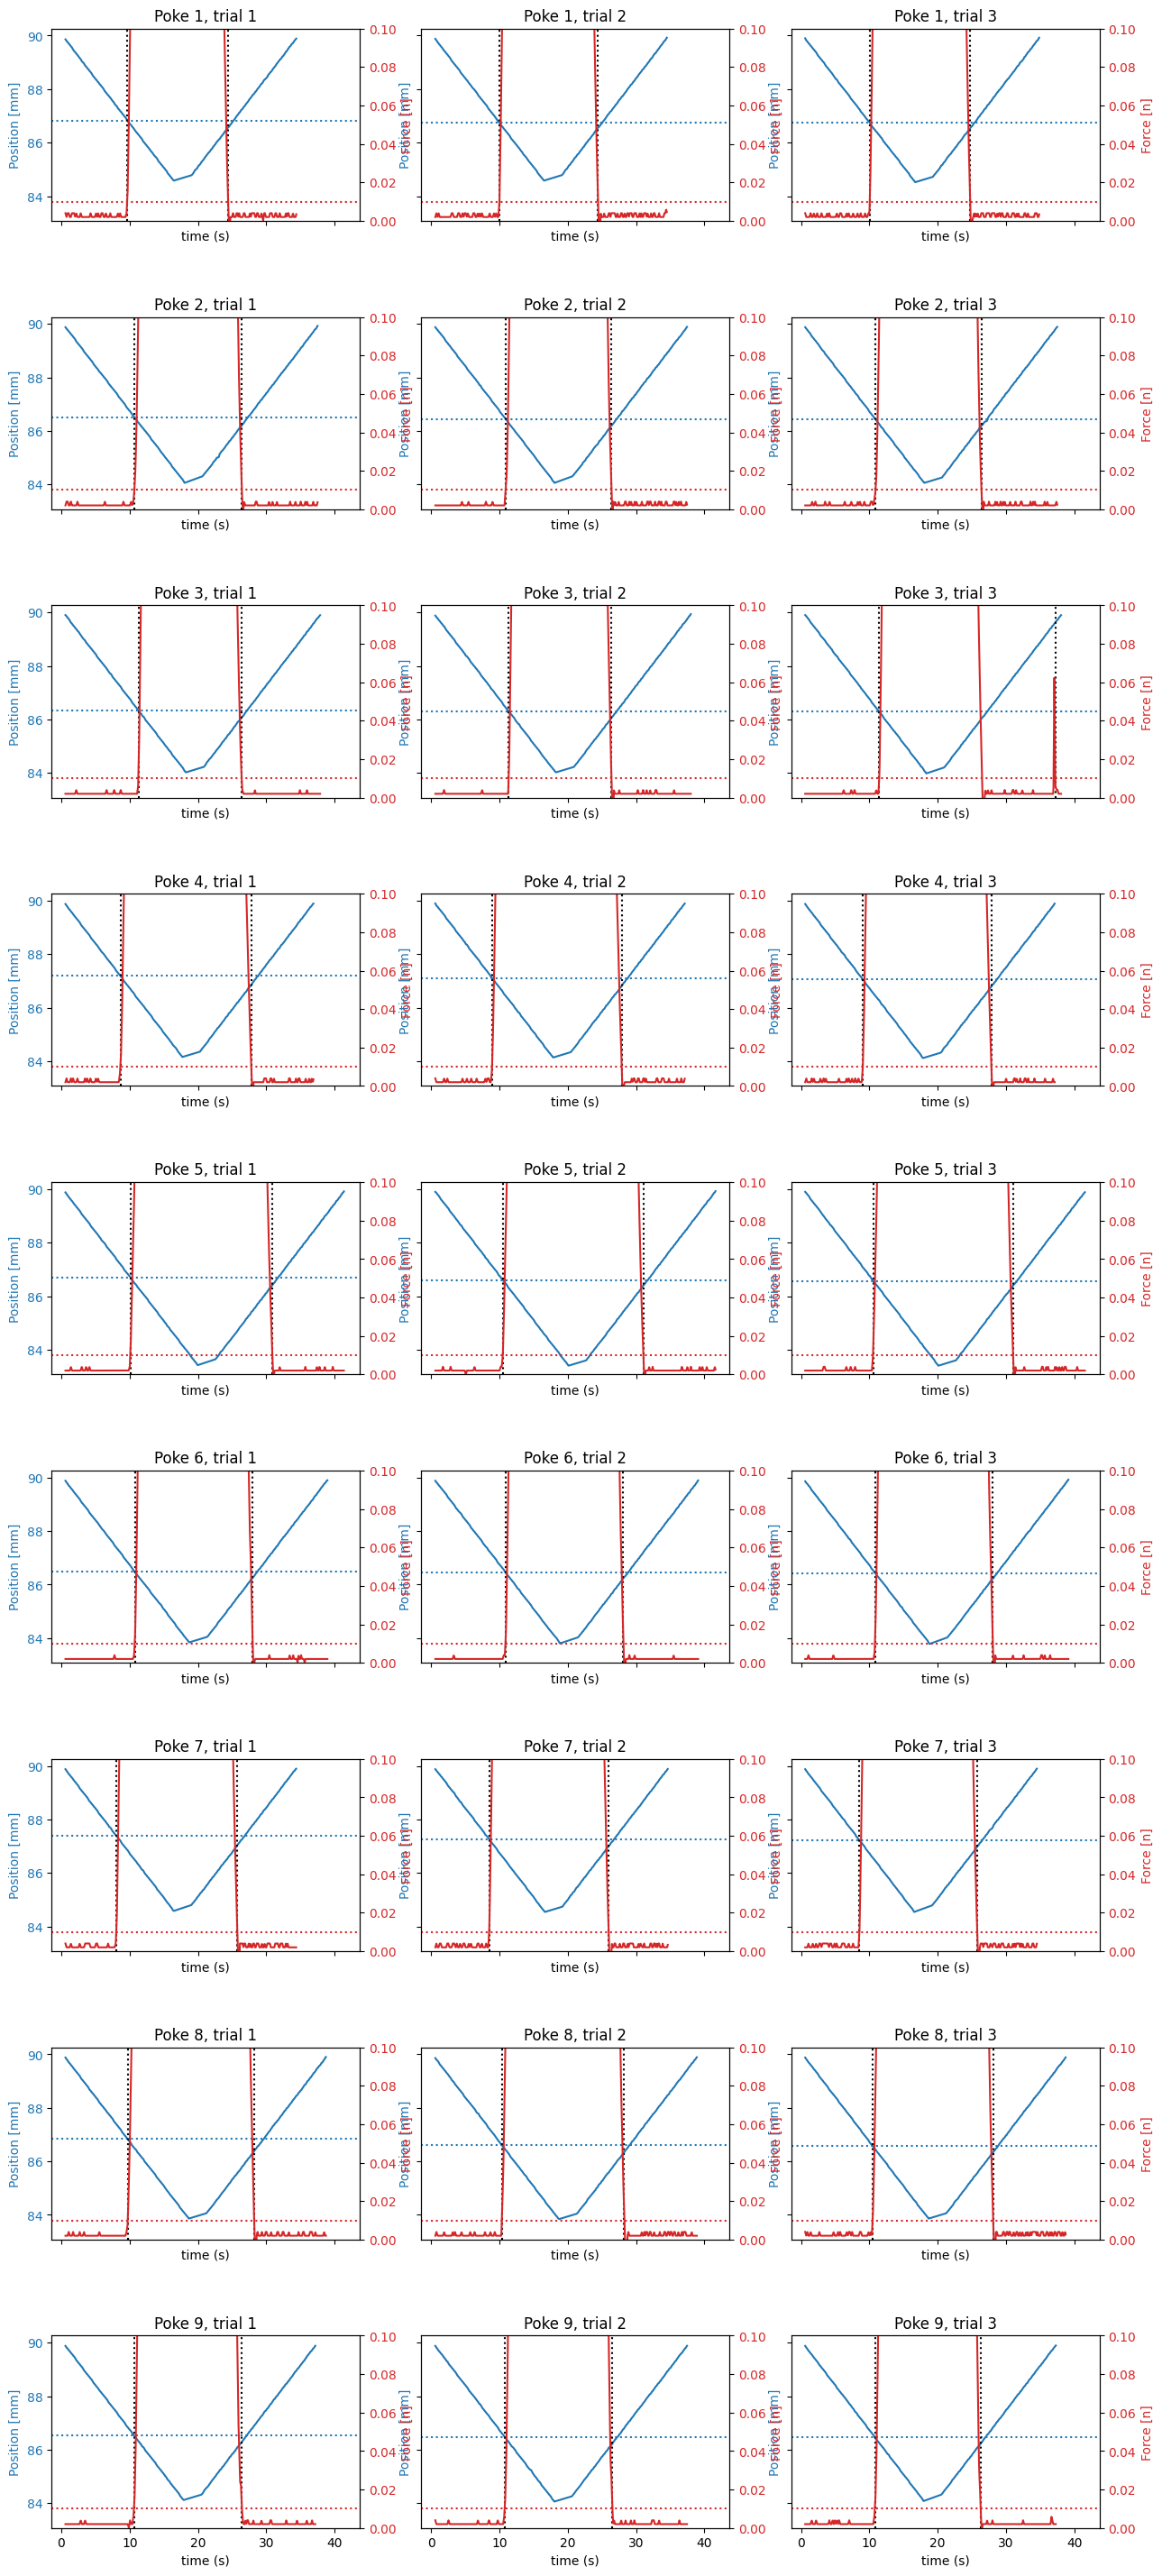

In [5]:
N_pokes = 9
N_repeats = 3

mat_dxs = np.zeros([N_pokes, N_repeats])

fig, axs = plt.subplots(nrows=N_pokes, ncols=N_repeats, figsize=(15, 4*N_pokes), sharey=True, sharex=True)
for i_poke in range(N_pokes):
    for i_repeat in range(N_repeats):
        df_data_i = list_poke_dfs[i_poke][i_repeat]
        ax1, ax2 = plot_pos_and_force_over_time(df_data_i, axs[i_poke][i_repeat])

        force_threshold = 0.01
        i_start, i_end, x_start, x_bottom = get_compression_posns(df_data_i, force_threshold)
        dx_compression = x_bottom - x_start

        print(f"Poke {i_poke+1} test {i_repeat+1}, Compression start at {x_start:.3f}, Compression bottom at {x_bottom:.3f}, dx is {dx_compression:.3f}")
        ax1.axhline(y=x_start, color="tab:blue", linestyle=":")
        ax2.axhline(y=force_threshold, color="tab:red", linestyle=":")
        ax1.axvline(x=df_data_i["time_s"][i_start], color="k", linestyle=":")
        ax1.axvline(x=df_data_i["time_s"][i_end], color="k", linestyle=":")
        
        plt.title(f"Poke {i_poke+1}, trial {i_repeat+1}")
        ax2.set_ylim([0, 0.1])

        mat_dxs[i_poke, i_repeat] = dx_compression
        
fig.subplots_adjust(hspace=0.5)

In [16]:
HOME_OFFSET_FROM_SURFACE_MM = 0.5
def get_compression_posns_posnbased(df_data, force_threshold):
    mask_compressing = df_data["force_N"] > force_threshold
    i_compress_start, i_compress_end = np.nonzero(mask_compressing)[0][[0, -1]] # Grab first and last indices above threshold
    x_start = df_data_i["position_mm"][i_compress_start]

    x_home = x_start + HOME_OFFSET_FROM_SURFACE_MM # 2mm offset from surface
    # Now compare against the bottomed out position to find the dx
    x_bottom = np.min(df_data_i["position_mm"])

    mask_probe_below_home = df_data["position_mm"] <= x_home
    i_start, i_end = np.nonzero(mask_probe_below_home)[0][[0, -1]]
    
    return i_start, i_end, x_start, x_bottom

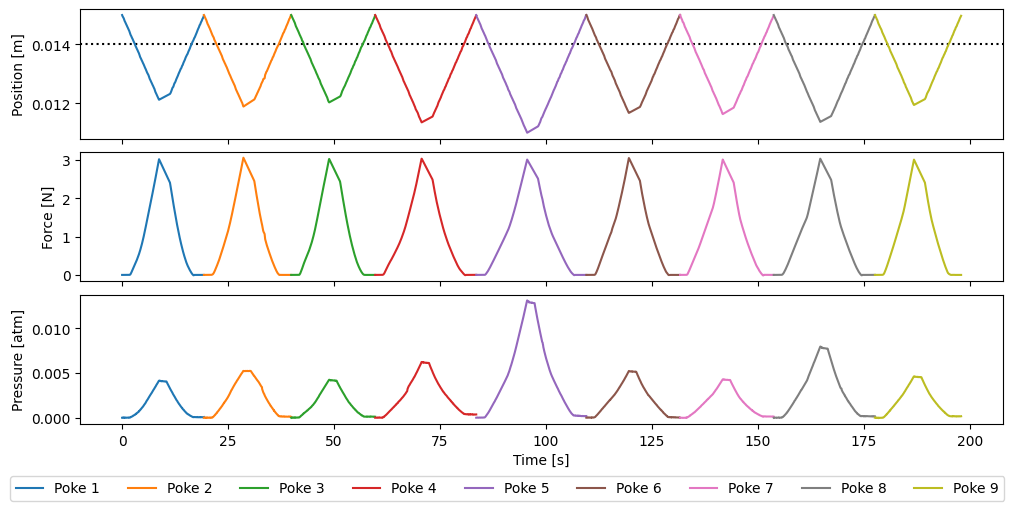

In [17]:
# For the first trial of each poke:
# - Crop the timestamps to just around when force is non-zero, padded on each side by 3 seconds
# - Shift later poke datasets so that they happen one-after-another
PADDING_S = 0
Z_PAD_TOP = 0.014
Z_START = Z_PAD_TOP + HOME_OFFSET_FROM_SURFACE_MM/1000
last_end_time = 0
processed_dfs = []
for i_poke in range(9):
    df_i = list_poke_dfs[i_poke][0]
    force_threshold = 0.01
    # i_start, i_end, x_start, x_bottom = get_compression_posns(df_i, force_threshold)
    i_start, i_end, x_start, x_bottom = get_compression_posns_posnbased(df_i, force_threshold)

    # i_end += 20

    # Shift the timestamps so that we only have the active poke times, +- PADDING_S seconds for padding
    # df_i_cropped = df_i
    df_i_cropped = df_i.iloc[i_start:i_end]
    df_i_cropped_shifted = df_i_cropped.copy(deep=True)
    df_i_cropped_shifted.loc[:, "time_s"] += (-df_i_cropped_shifted["time_s"].iloc[0]) + last_end_time + PADDING_S
    last_end_time = df_i_cropped_shifted["time_s"].iloc[-1]

    # Shift the poke position so that they all make contact at the same z
    df_i_cropped_shifted.loc[:, "position_mm"] *= 1/1000 # Convert to meters
    df_processed = df_i_cropped_shifted.rename(columns={"position_mm": "position_m"})
    df_processed.loc[:, "position_m"] += (-df_processed["position_m"].iloc[0]) + Z_START + 0.0005

    # Zero the pressure to the initial pressure
    df_processed.loc[:, "pressure_atm"] += (-df_processed["pressure_atm"].iloc[0])


    processed_dfs.append(df_processed)

fig, axs = plt.subplots(figsize=(10, 5), ncols=1, nrows=3, sharex=True, layout="constrained")
axs[0].axhline(Z_PAD_TOP, color="k", linestyle=":")
for i_poke, df_i in enumerate(processed_dfs):
    axs[0].plot(df_i["time_s"], df_i["position_m"], label=f"Poke {i_poke + 1}")
    axs[0].set_ylabel("Position [m]")
    
    axs[1].plot(df_i["time_s"], df_i["force_N"])
    axs[1].set_ylabel("Force [N]")
    
    axs[2].plot(df_i["time_s"], df_i["pressure_atm"])
    axs[2].set_ylabel("Pressure [atm]")
    
    axs[2].set_xlabel("Time [s]")
fig.legend(loc="outside lower center", ncols=9)

In [18]:
## Output csvs for each poke dataset
# Real poke numbering:
# | 1 | 2 | 3 |
# |---+---+---|
# | 4 | 5 | 6 |
# |---+---+---|
# | 7 | 8 | 9 |
# Simulated poke numbering
# | 2 | 6 | 7 |
# |---+---+---|
# | 1 | 5 | 8 |
# |---+---+---|
# | 3 | 4 | 9 |
dict_poke_idx_sim2real = {
    1: 4,
    2: 1,
    3: 7,
    4: 8,
    5: 5,
    6: 2,
    7: 3,
    8: 6,
    9: 9    
}

dict_poke_idx_real2sim = {
    1: 2,
    2: 6,
    3: 7,
    4: 1,
    5: 5,
    6: 8,
    7: 3,
    8: 4,
    9: 9
}

OUT_DIR = Path("../Data/Gilbert/Thigh_pad/pokes/adjusted")
for i_poke, df_i in enumerate(processed_dfs):
    filepath_i = OUT_DIR / f"adjusted_newton_poke_{i_poke + 1}_1.csv"
    df_i.to_csv(filepath_i, index=False)

In [ ]:
# Now run the sim_franka_nine_poke.py script